# 🌍 Explore CMIP6 SSP5-8.5 Data via Zarr / Google Cloud Storage

This notebook loads CMIP6 climate model output directly from **cloud-optimised Zarr stores**
hosted on Google Cloud Storage — no local download required.

Two technologies do the heavy lifting:

| Technology | Role |
|---|---|
| [**CMIP6 Zarr catalogue**](https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv) | A CSV index of every available Zarr store — filter it like a dataframe |
| [**Zarr + fsspec**](https://zarr.readthedocs.io/) | Stream chunks of data lazily over HTTP from GCS — only what you actually use is downloaded |

**What we'll do**

1. Query the CMIP6 Zarr catalogue for near-surface air temperature (`tas`) from the **SSP5-8.5** scenario
2. Open the remote Zarr store lazily with `xarray` + `fsspec`
3. Map the temperature field on a proper geographic projection
4. Build an **area-weighted global-mean** temperature series
5. Compute the **warming anomaly** relative to a 2015–2025 baseline

> ⚠️ **Live data.** Cells stream data from Google Cloud Storage in real time.
> An internet connection is required; the first compute cell may take ~30–60 s depending on bandwidth.

## ⚙️ Setup

Imports plus a little plot styling so the figures look clean.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import fsspec

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# --- light, consistent plot styling ---
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 11,
})

## 🔎 Querying the CMIP6 Zarr catalogue

The CMIP6 Zarr catalogue is a single CSV file hosted on Google Cloud Storage. Each row points to
one Zarr store (one model × variable × experiment × member combination). We filter it like a
regular Pandas dataframe using the standard CMIP6 facets (`variable_id`, `experiment_id`,
`source_id`, `member_id`, `table_id`, `grid_label`).

In [2]:
df = pd.read_csv(
    "https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv"
)
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


## 🔧 Choosing variables, experiments, ensembles, and timesteps

Before filtering the catalogue, it helps to understand what each facet means.

### 📊 Variable (`variable_id`)

CMIP6 variables follow the [CF conventions](https://cfconventions.org/) and are grouped into
**MIP tables** (e.g. `Amon` = monthly atmosphere).

| Variable ID | Long name | Units | MIP table |
|---|---|---|---|
| `tas` | 🌡️ Near-surface air temperature | K | `Amon` |
| `pr` | 🌧️ Precipitation | kg m⁻² s⁻¹ | `Amon` |
| `psl` | 💨 Sea-level pressure | Pa | `Amon` |
| `tos` | 🌊 Sea surface temperature | °C | `Omon` |
| `siconc` | 🧊 Sea ice area fraction | % | `SImon` |

### 🧪 Experiment (`experiment_id`)

Experiments define the **forcing scenario** applied to the model.

| Experiment | Activity | Period | Description |
|---|---|---|---|
| `historical` | `CMIP` | 1850–2014 | 📜 Observed forcings (GHGs, aerosols, land use) |
| `piControl` | `CMIP` | 500+ yrs | ⚖️ Pre-industrial control — constant 1850 forcings |
| `ssp126` | `ScenarioMIP` | 2015–2100 | 🌿 Low emissions — ~1.9 °C warming by 2100 |
| `ssp245` | `ScenarioMIP` | 2015–2100 | 🌤️ Intermediate emissions — ~2.7 °C warming by 2100 |
| `ssp370` | `ScenarioMIP` | 2015–2100 | ⚠️ High emissions — ~3.6 °C warming by 2100 |
| `ssp585` | `ScenarioMIP` | 2015–2100 | 🔥 Very high emissions ("business as usual") — ~4.4 °C warming by 2100 |

> The SSP numbers encode both a **Shared Socioeconomic Pathway** (1–5, from sustainability to fossil-fuel development) and a **radiative forcing level** by 2100 in W m⁻² (1.9, 2.6, 4.5, 7.0, 8.5).

### 🎲 Ensemble member (`member_id`)

The `member_id` tag `r<i>i<j>p<k>f<l>` identifies a specific run within a model's ensemble:

| Token | Meaning | Typical value |
|---|---|---|
| `r` | **R**ealization — different initial conditions | 1, 2, 3 … |
| `i` | **I**nitialization method | 1 |
| `p` | **P**hysics version | 1 |
| `f` | **F**orcing index | 1 |

`r1i1p1f1` is the standard first member. When multiple realizations exist (e.g. `r1`–`r10`), their
spread quantifies **internal variability**. How much the climate can differ by chance even under
identical external forcing.

### ⏱️ Timestep / Output frequency (`table_id`)

The `table_id` encodes both the **model realm** and the **output frequency** in a single string.
The prefix identifies the realm and the suffix the frequency:

| Table ID | Realm | Frequency | Typical use |
|---|---|---|---|
| `Amon` | ☁️ Atmosphere | Monthly | Standard atmospheric diagnostics (this notebook) |
| `Lmon` | 🌿 Land | Monthly | Soil moisture, vegetation, runoff |
| `Omon` | 🌊 Ocean | Monthly | SST, salinity, currents |
| `SImon` | 🧊 Sea ice | Monthly | Sea-ice concentration, thickness |
| `day` | ☁️ Atmosphere | Daily | Extremes, variability studies |
| `3hr` | ☁️ Atmosphere | 3-hourly | Precipitation intensity, diurnal cycle |
| `6hrLev` | ☁️ Atmosphere | 6-hourly on pressure levels | Reanalysis comparison, composites |
| `Ayr` | ☁️ Atmosphere | Annual | Long multi-century runs |
| `fx` | 🗺️ (any) | Time-invariant | Grid-cell area (`areacella`), orography, land mask |

> **Rule of thumb:** higher frequency = larger files, more compute. Monthly (`Amon`) is the best
> starting point for climatological studies. Switch to `day` or sub-daily only when your science
> question requires resolving shorter time scales (e.g. heat waves, diurnal precipitation).

### 🗂️ Grid label (`grid_label`)

The `grid_label` tells you **which grid version** of the data you are getting. Modelling centres
can publish the same variable on more than one grid:

| Label | Meaning | When to use |
|---|---|---|
| `gn` | **Native grid** — the model's own computational grid | Best for single-model analysis; preserves original resolution and structure |
| `gr` | **Regridded** — interpolated to a regular lat/lon grid by the modelling centre | Preferred for multi-model comparisons; all models on the same grid |
| `gr1`, `gr2` | Alternative regridded versions (different target resolutions) | Check the model's documentation for the exact resolution |
| `gnz` / `grz` | Zonal mean on native / regridded grid | Pre-computed meridional averages |

**Why it matters:** some models use non-standard grids internally (e.g. a cubed-sphere atmosphere
or a tripolar ocean). On those grids, `lat` and `lon` may not be simple 1-D coordinate arrays —
they can be 2-D. Choosing `gr` guarantees a regular grid that `xarray` handles transparently.

> In the catalogue above you can see both `gn` and `gr`/`gr1` rows for the same model. For a
> quick cross-model comparison, filter to a single label (e.g. `df[df.grid_label == "gn"]`) so
> you don't accidentally open the same data twice.

In [3]:
'''Load monthly near-surface air temperature (tas) from the SSP5-8.5 (ssp585) scenario,
ensemble member r1i1p1f1, on a regular grid, and return it as an xarray Dataset.
'''

variable = "tas"
experiment = "ssp585"
ensemble = "r1i1p1f1"
grid = "gr"

df_tas = df[
    (df.variable_id == variable)
    & (df.experiment_id == experiment)
    & (df.member_id == ensemble)
    & (df.table_id == "Amon")
    & (df.grid_label == grid)
]
df_tas


,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
279556,ScenarioMIP,IPSL,IPSL-CM6A-LR,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR...,NaN,20190903
295111,ScenarioMIP,NIMS-KMA,KACE-1-0-G,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/NIMS-KMA/KACE-1-0...,NaN,20190920
360524,ScenarioMIP,CAS,FGOALS-f3-L,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/CAS/FGOALS-f3-L/s...,NaN,20191013
420035,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20200225
425558,ScenarioMIP,EC-Earth-Consortium,EC-Earth3,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20200310
449106,ScenarioMIP,THU,CIESM,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/THU/CIESM/ssp585/...,NaN,20200605
498440,ScenarioMIP,E3SM-Project,E3SM-1-1,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/E3SM-Project/E3SM...,NaN,20201117
500309,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-Veg-LR,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20201201
511768,ScenarioMIP,EC-Earth-Consortium,EC-Earth3-CC,ssp585,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/ScenarioMIP/EC-Earth-Consorti...,NaN,20210113


> **Check your understanding**
>
> 1. How many models in `df_tas` provide SSP5-8.5 `tas` on a regular grid?
> 2. What would you change in the filter to get **precipitation** instead of temperature?
> 3. What would you change to get the SSP1-2.6 (low emissions) scenario?

## 📂 Opening a Zarr store from Google Cloud Storage (lazy loading)

```python
ds = xr.open_zarr(fsspec.get_mapper(row.zstore), consolidated=True)
```

| Part | What it does |
|---|---|
| `row.zstore` | Picks the `zstore` path from the filtered catalogue — a GCS URI like `gs://cmip6/CMIP6/ScenarioMIP/...` |
| `fsspec.get_mapper(...)` | Wraps the GCS path in a filesystem-agnostic key→bytes mapping so `xarray` can read remote storage (GCS, S3, HTTP, local) with the same interface |
| `xr.open_zarr(..., consolidated=True)` | Opens the Zarr store **lazily** — only metadata is fetched now; actual data arrays stream on demand. `consolidated=True` reads a single pre-built `.zmetadata` file instead of one HTTP request per variable, which is much faster over remote storage |

> No data is downloaded at this point. `ds` only holds coordinates, dimensions, and attributes.
> Arrays are loaded into memory only when you index or compute on them.

In [4]:
# Explicitly choose a model — change this to experiment with different models
model = "IPSL-CM6A-LR"

row = df_tas[df_tas.source_id == model].iloc[0]
print(f"Opening: {row.source_id}  (institution: {row.institution_id})")
print(f"Store:   {row.zstore}")

ds = xr.open_zarr(fsspec.get_mapper(row.zstore), consolidated=True)
ds

Opening: IPSL-CM6A-LR  (institution: IPSL)
Store:   gs://cmip6/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/Amon/tas/gr/v20190903/


<xarray.Dataset> Size: 85MB
Dimensions:      (time: 1032, lat: 143, lon: 144, axis_nbounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16...
  * lat          (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon          (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    time_bounds  (time, axis_nbounds) datetime64[ns] 17kB dask.array<chunksize=(1032, 2), meta=np.ndarray>
    height       float64 8B ...
Dimensions without coordinates: axis_nbounds
Data variables:
    tas          (time, lat, lon) float32 85MB dask.array<chunksize=(600, 143, 144), meta=np.ndarray>
Attributes: (12/52)
    CMIP6_CV_version:       cv=6.2.3.5-2-g63b123e
    Conventions:            CF-1.7 CMIP-6.2
    EXPID:                  ssp585
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  IPSL-CM6A-LR model output prepared for CMIP6 / Sc...
    tracking_id:            hdl:21.14100/131c5ed5-c3f0-4c3a-bbc8-f66ed7799e03
    variable_id:            tas
    variant_info:           Each member starts from the corresponding member ...
    variant_label:          r1i1p1f1
    status:                 2019-10-25;created;by nhn2@columbia.edu

## 💾 Data footprint

How large is the full dataset, in MB per simulation year?

In [6]:
print(f'Data footprint: {ds.nbytes / 1e6 / (ds.sizes["time"] / 12):.2f} MB per simulation year')
print(f'Total data size: {ds.nbytes / 1e9:.2f} GB')

Data footprint: 0.99 MB per simulation year
Total data size: 0.09 GB


### Longitude convention

This model stores longitudes on a **0–360° grid** (e.g. `0.625, 1.875, ..., 359.4`).
Most geographic operations — and human intuition — use a **−180 to +180° convention**.
We convert once here and use `ds_180` for everything that follows.

```python
# shift 0–360 to -180–180
ds_180 = ds.assign_coords(lon=(ds.lon + 180) % 360 - 180).sortby("lon")
```

The modulo operation `(lon + 180) % 360 - 180` maps any longitude ≥ 180° to a negative value:
- 180° → 0°   (no change)
- 270° → −90° (becomes 90°W)
- 359° → −1°  (just west of Greenwich)

<div style="display:flex; align-items:center; gap:1rem;">
  <img src="assets/360.png" alt="0–360 longitude convention" style="max-width:45%;">
  <span style="font-size:2rem;">&#8594;</span>
  <img src="assets/180.png" alt="−180–180 longitude convention" style="max-width:45%;">
</div>

In [7]:
ds_180 = ds.assign_coords(lon=(ds.lon + 180) % 360 - 180).sortby("lon")

print("Before shift — lon range:", float(ds.lon.min()), "→", float(ds.lon.max()))
print(
    "After shift  — lon range:", float(ds_180.lon.min()), "→", float(ds_180.lon.max())
)

Before shift — lon range: 0.0 → 357.5
After shift  — lon range: -180.0 → 177.5


## 🗺️ Map a single month

We select a single month with `.sel(time="2050-01")` and render it on a Robinson projection.
This triggers the first actual data download — only the one or two Zarr chunks covering January 2050.

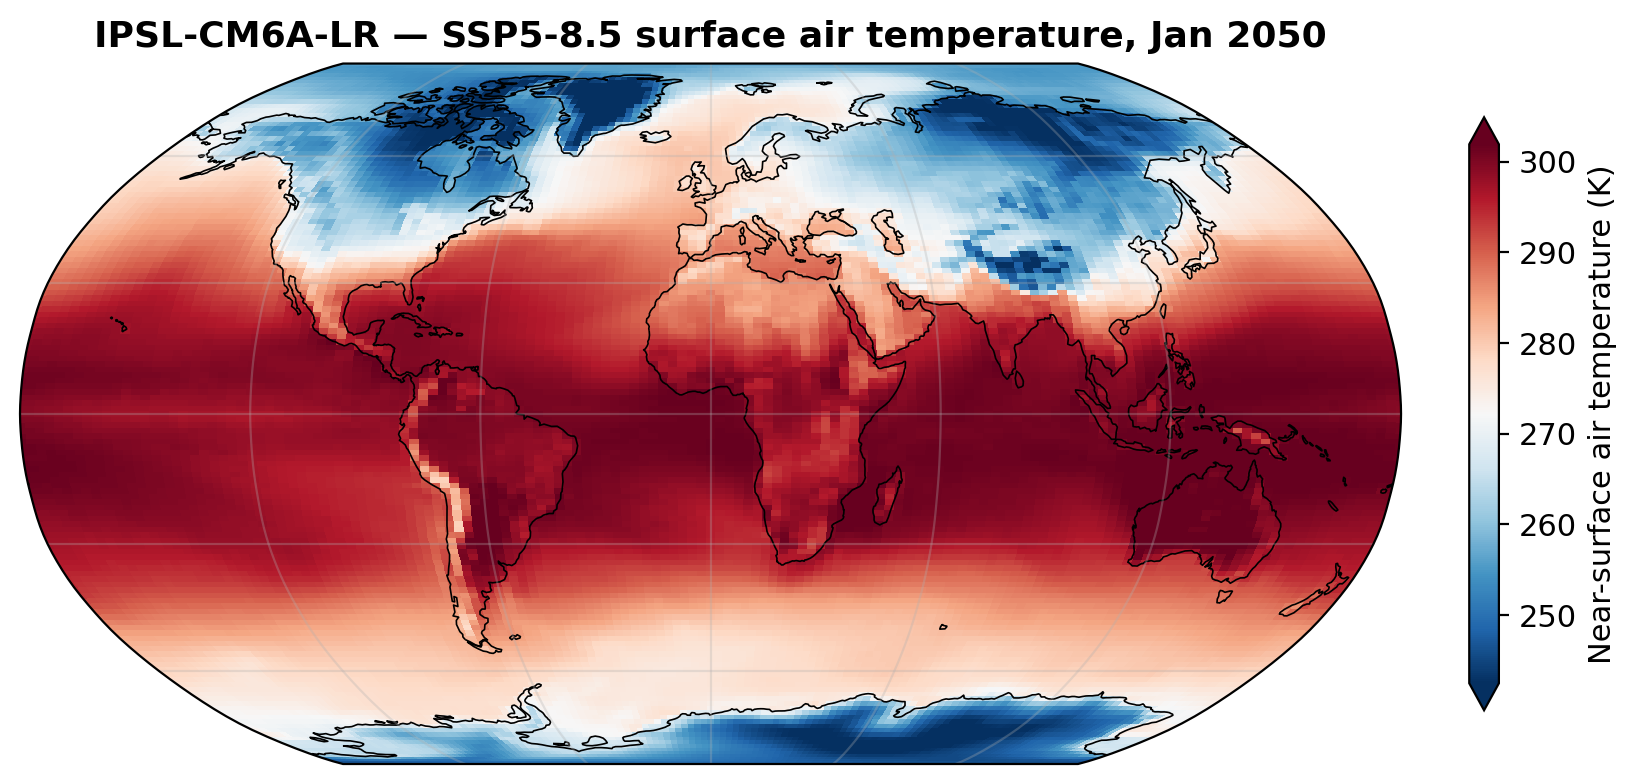

In [8]:
snapshot = ds_180.tas.sel(time="2050-01").squeeze()

fig = plt.figure(figsize=(11, 5.5))
ax = plt.axes(projection=ccrs.Robinson())

snapshot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    robust=True,
    cbar_kwargs={
        "label": "Near-surface air temperature (K)",
        "shrink": 0.7,
        "pad": 0.04,
    },
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(alpha=0.3)
ax.set_global()
ax.set_title(f"{model} — SSP5-8.5 surface air temperature, Jan 2050")
plt.show()


### 🔍 Plotting a regional subset

To zoom into a specific region, subset the array **before** plotting with `.sel(lat=slice(...), lon=slice(...))`.
This streams only the relevant chunk from the remote store instead of the full global field.

| Change vs global map | Why |
|---|---|
| `.sel(lat=slice(...), lon=slice(...))` | Clips the array to the bounding box — less data, faster render |
| `ccrs.PlateCarree()` | Flat projection works better than Robinson for regional views |
| `ax.set_extent([W, E, S, N])` | Zooms the map frame to the region of interest |
| `draw_labels=True` on gridlines | Adds lat/lon tick labels on the axes |
| `cfeature.BORDERS` | Shows country borders — useful at regional scale |

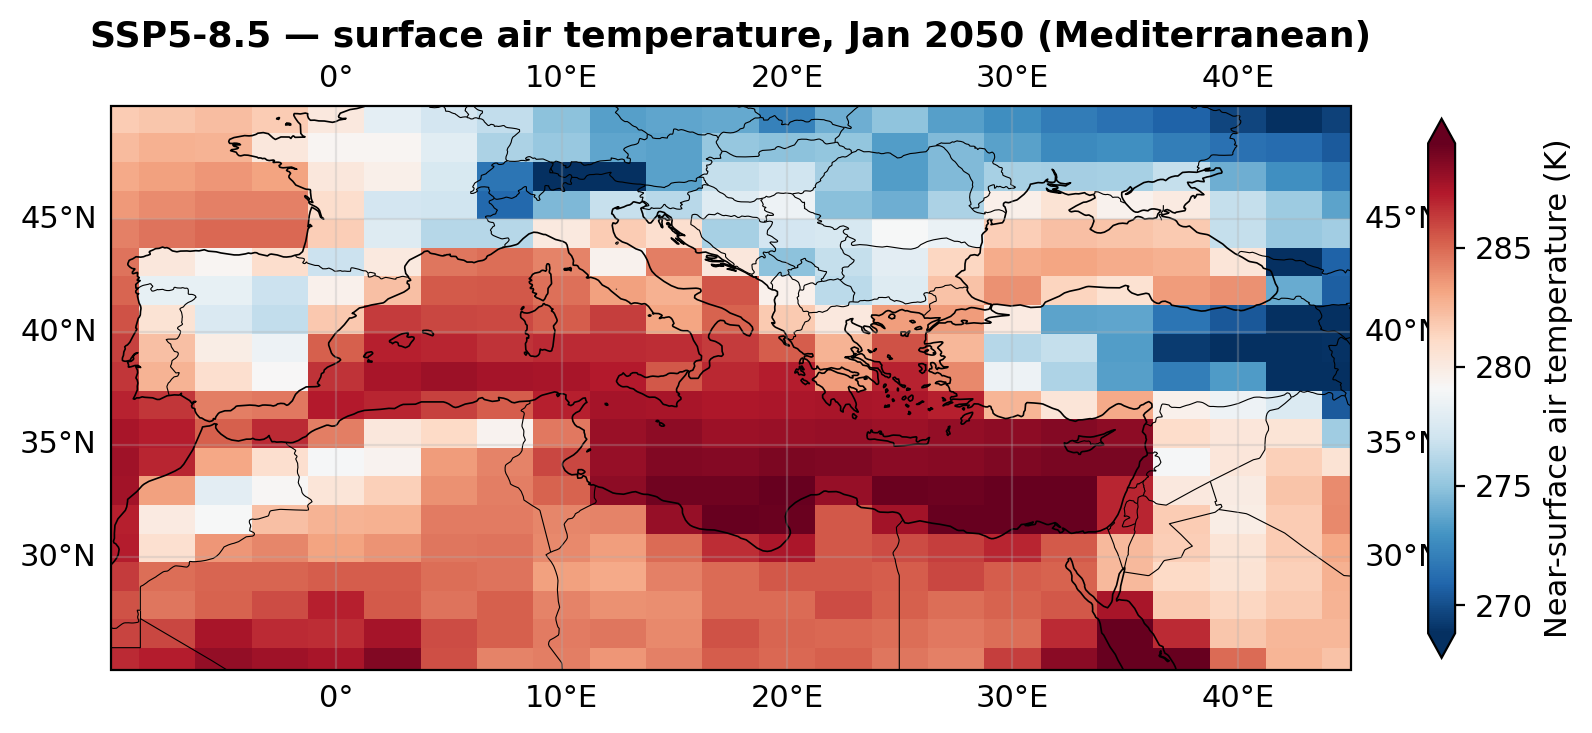

In [9]:
# e.g. Mediterranean region
lon_min, lon_max = -10, 45
lat_min, lat_max = 25, 50

ds_180 = ds.assign_coords(lon=(ds.lon + 180) % 360 - 180).sortby("lon")
subset = (
    ds_180.tas.sel(time="2050-01", lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    .squeeze()
    .sortby("lat")
)


fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

subset.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    robust=True,
    cbar_kwargs={"label": "Near-surface air temperature (K)", "shrink": 0.7},
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.gridlines(draw_labels=True, alpha=0.3)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title(
    "SSP5-8.5 — surface air temperature, Jan 2050 (Mediterranean)", fontweight="bold"
)
plt.show()


### Seasonal climatology

A four-panel seasonal mean over the full **2015–2100** SSP5-8.5 projection. This triggers a real
computation across all timesteps streamed from Google Cloud Storage, so give it a moment (~30–60 s).

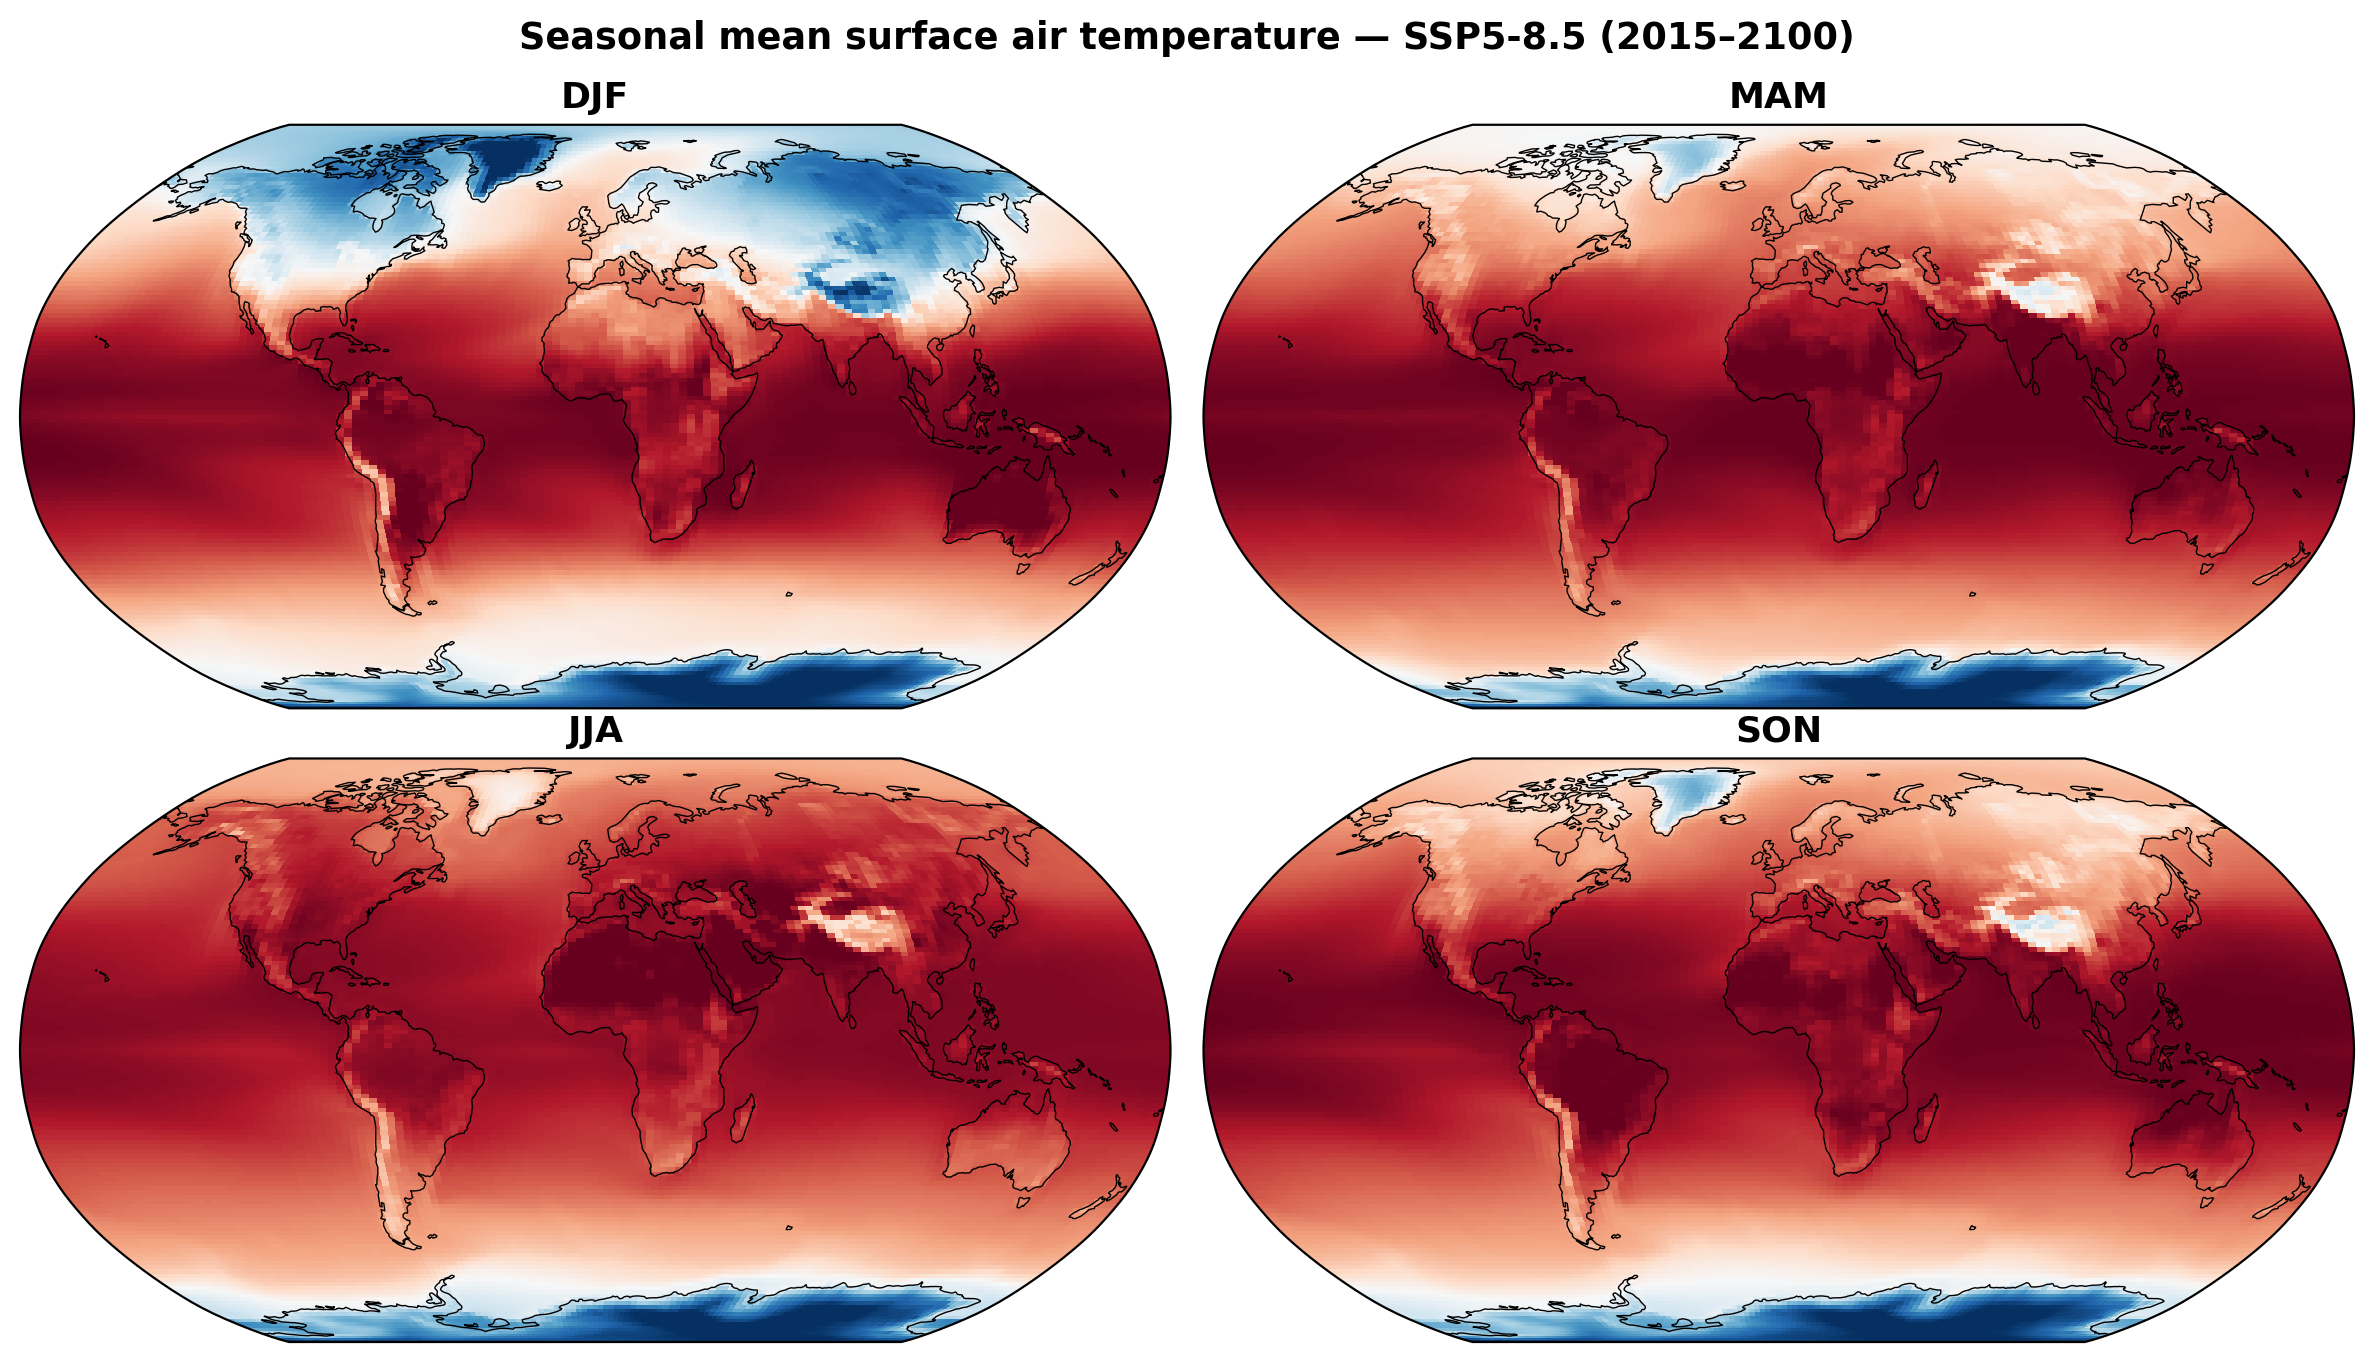

In [10]:
seasonal = ds.tas.groupby("time.season").mean("time")
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    2, 2, figsize=(12, 7), subplot_kw={"projection": ccrs.Robinson()}
)
for ax, season in zip(axes.flat, seasons):
    seasonal.sel(season=season).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        robust=True,  # clips the colormap to the 2nd–98th percentile of the data, so extreme outliers don't wash out the color scale
        add_colorbar=False,
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_global()
    ax.set_title(season)

fig.suptitle(
    "Seasonal mean surface air temperature — SSP5-8.5 (2015–2100)",
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


> **Check your understanding**
>
> 1. What does `robust=True` do in `.plot()`? (Hint: try `robust=False` and compare)
> 2. Why does the Arctic warm faster than the tropics? (This pattern has a name — what is it?)
> 3. How would you compute a seasonal climatology for just the period 2070–2100?

## 🌡️ Area-weighted global-mean temperature

A simple average over grid cells is biased. Cells near the poles are much smaller than at the equator.
Since `ds` is on a regular lat/lon grid (`gr`), cell area is proportional to `cos(lat)`, so we use
xarray's built-in `weighted()` method.

![Cell weights](assets/weights.png)

In [11]:
weights = np.cos(np.deg2rad(ds_180.lat))
ta_timeseries = ds_180.tas.weighted(weights).mean(dim=["lon", "lat"])


This still returns a lazy dask array. The `.load()` call below triggers the download and computation.

In [12]:
print("Still lazy:", ta_timeseries)
print("\nTriggering download + computation...")
%time ta_timeseries = ta_timeseries.load()
print("Done. Shape:", ta_timeseries.shape)


Still lazy: <xarray.DataArray 'tas' (time: 1032)> Size: 4kB
dask.array<truediv, shape=(1032,), dtype=float32, chunksize=(600,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
    height   float64 8B ...
Attributes:
    cell_measures:       area: areacella
    cell_methods:        area: time: mean
    description:         near-surface (usually, 2 meter) air temperature
    history:             none
    interval_operation:  900 s
    interval_write:      1 month
    long_name:           Near-Surface Air Temperature
    online_operation:    average
    standard_name:       air_temperature
    units:               K

Triggering download + computation...
CPU times: total: 891 ms
Wall time: 5.1 s
Done. Shape: (1032,)


### 📉 Visualising the global-mean time series

We plot the raw monthly values in light grey and overlay a **12-month rolling mean** to filter out
the seasonal cycle and highlight the long-term warming trend.

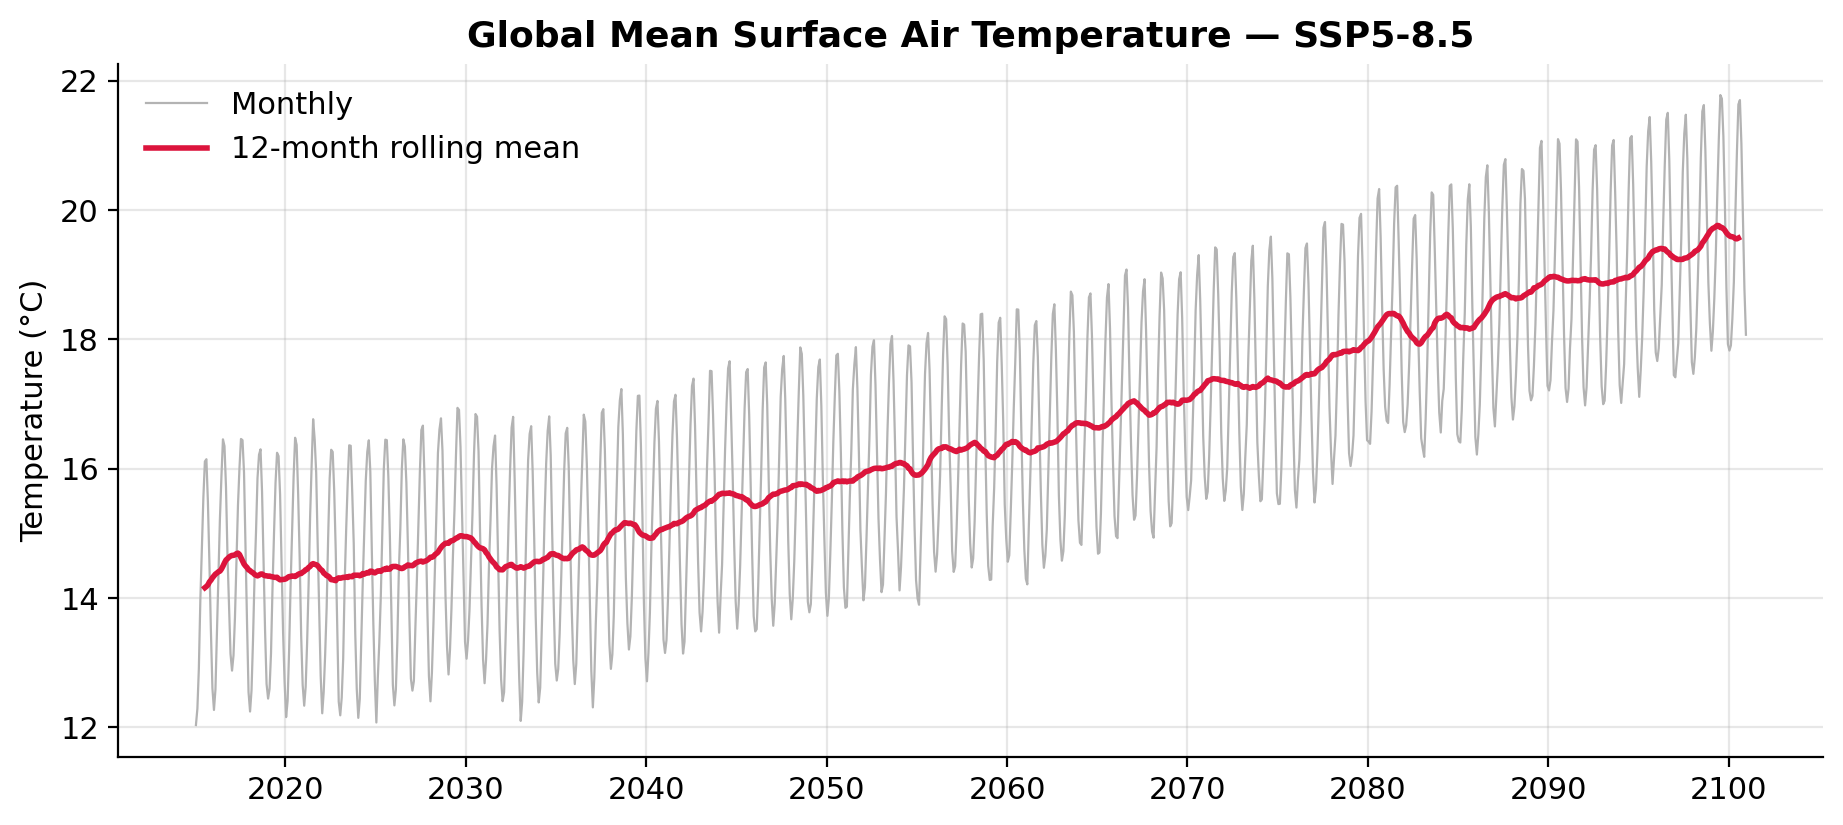

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ta_C = ta_timeseries - 273.15 # convert from K to °C

ta_C.plot(ax=ax, color='0.7', lw=0.8, label='Monthly')
ta_C.rolling(time=12, center=True).mean().plot(
    ax=ax, color='crimson', lw=2, label='12-month rolling mean')

ax.set_title('Global Mean Surface Air Temperature — SSP5-8.5')
ax.set_ylabel('Temperature (°C)')
ax.set_xlabel('')
ax.legend(frameon=False)
plt.show()

### 📍 Temperature time series at a specific location

Instead of a global mean, extract the temperature at a single grid point using `.sel()` with
`method='nearest'`. `.sel(lat=..., lon=..., method='nearest')` snaps to the closest grid cell.
Change `target_lat` and `target_lon` to any location you are interested in.

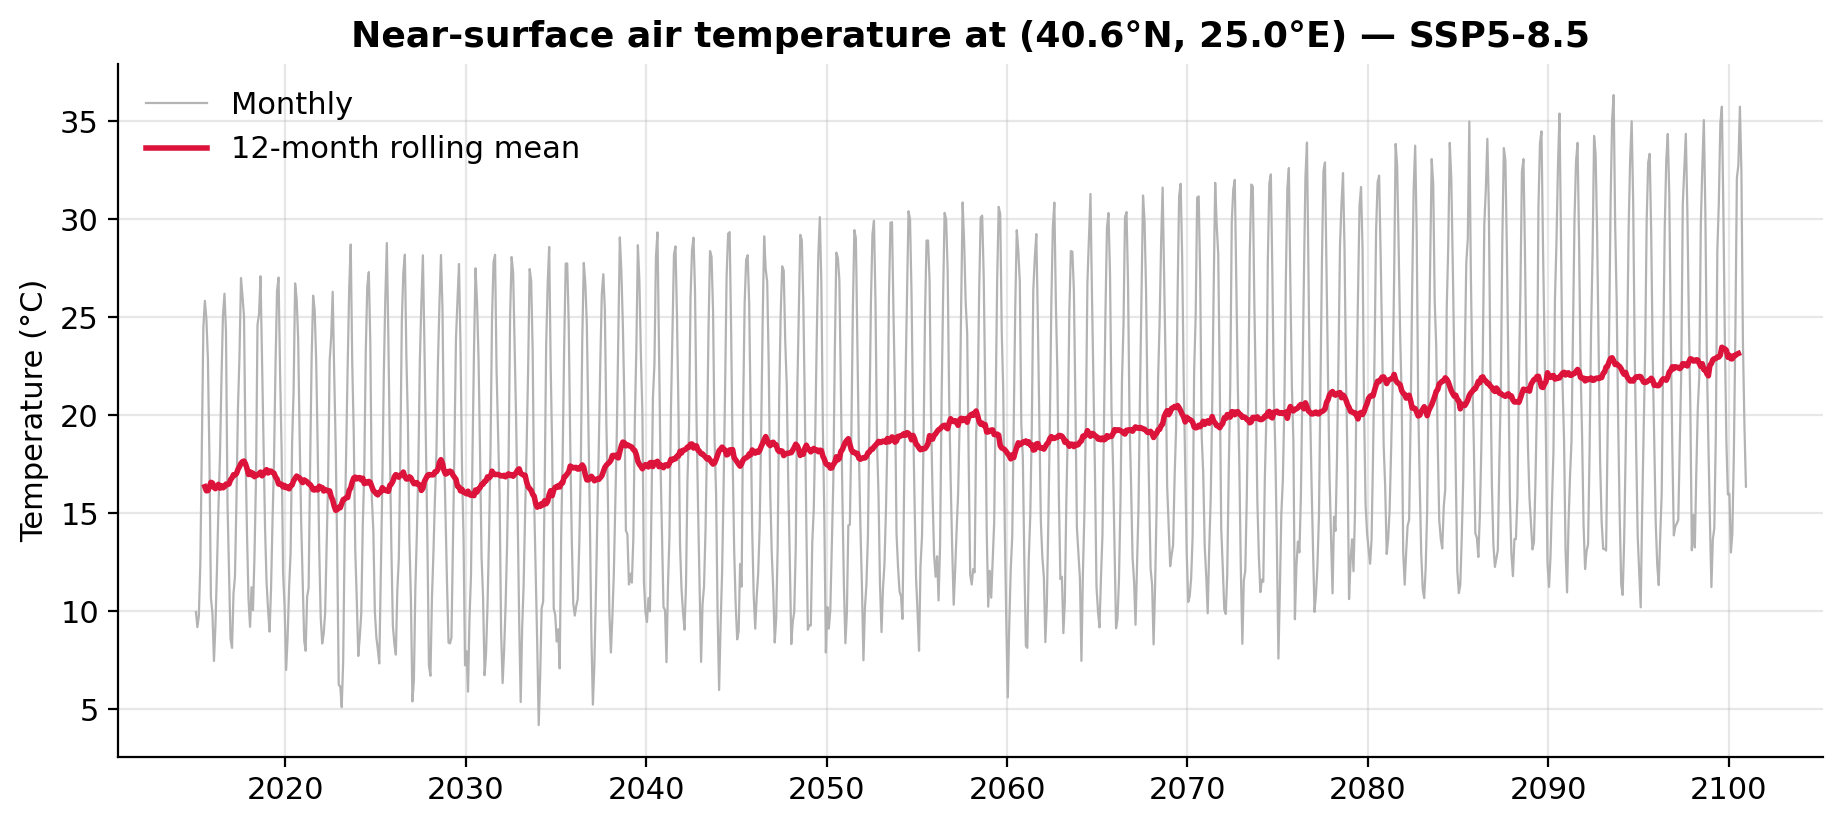

In [14]:
# Target location — change to any lat/lon you like
target_lat = 41.133  # Xanthi, Greece
target_lon = 24.883

point = ds_180.tas.sel(lat=target_lat, lon=target_lon, method="nearest")

point_C = point - 273.15  # convert from K to °C


fig, ax = plt.subplots(figsize=(11, 4.5))
point_C.plot(ax=ax, color="0.7", lw=0.8, label="Monthly")
point_C.rolling(time=12, center=True).mean().plot(
    ax=ax, color="crimson", lw=2, label="12-month rolling mean"
)

actual_lat = float(point.lat)
actual_lon = float(point.lon)
ax.set_title(
    f"Near-surface air temperature at ({actual_lat:.1f}°N, {actual_lon:.1f}°E) — SSP5-8.5",
    fontweight="bold",
)
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.show()


## 📈 Warming relative to early projection period

Climate signals read more clearly as **anomalies** (differences from a reference period).
Here We take a **2015–2025** reference baseline from the start of the SSP5-8.5 run, subtract it, and average to annual values —
warm years above the line, cool years below.

```
anomaly(t) = T(t) − mean(T, 2015–2025)
```

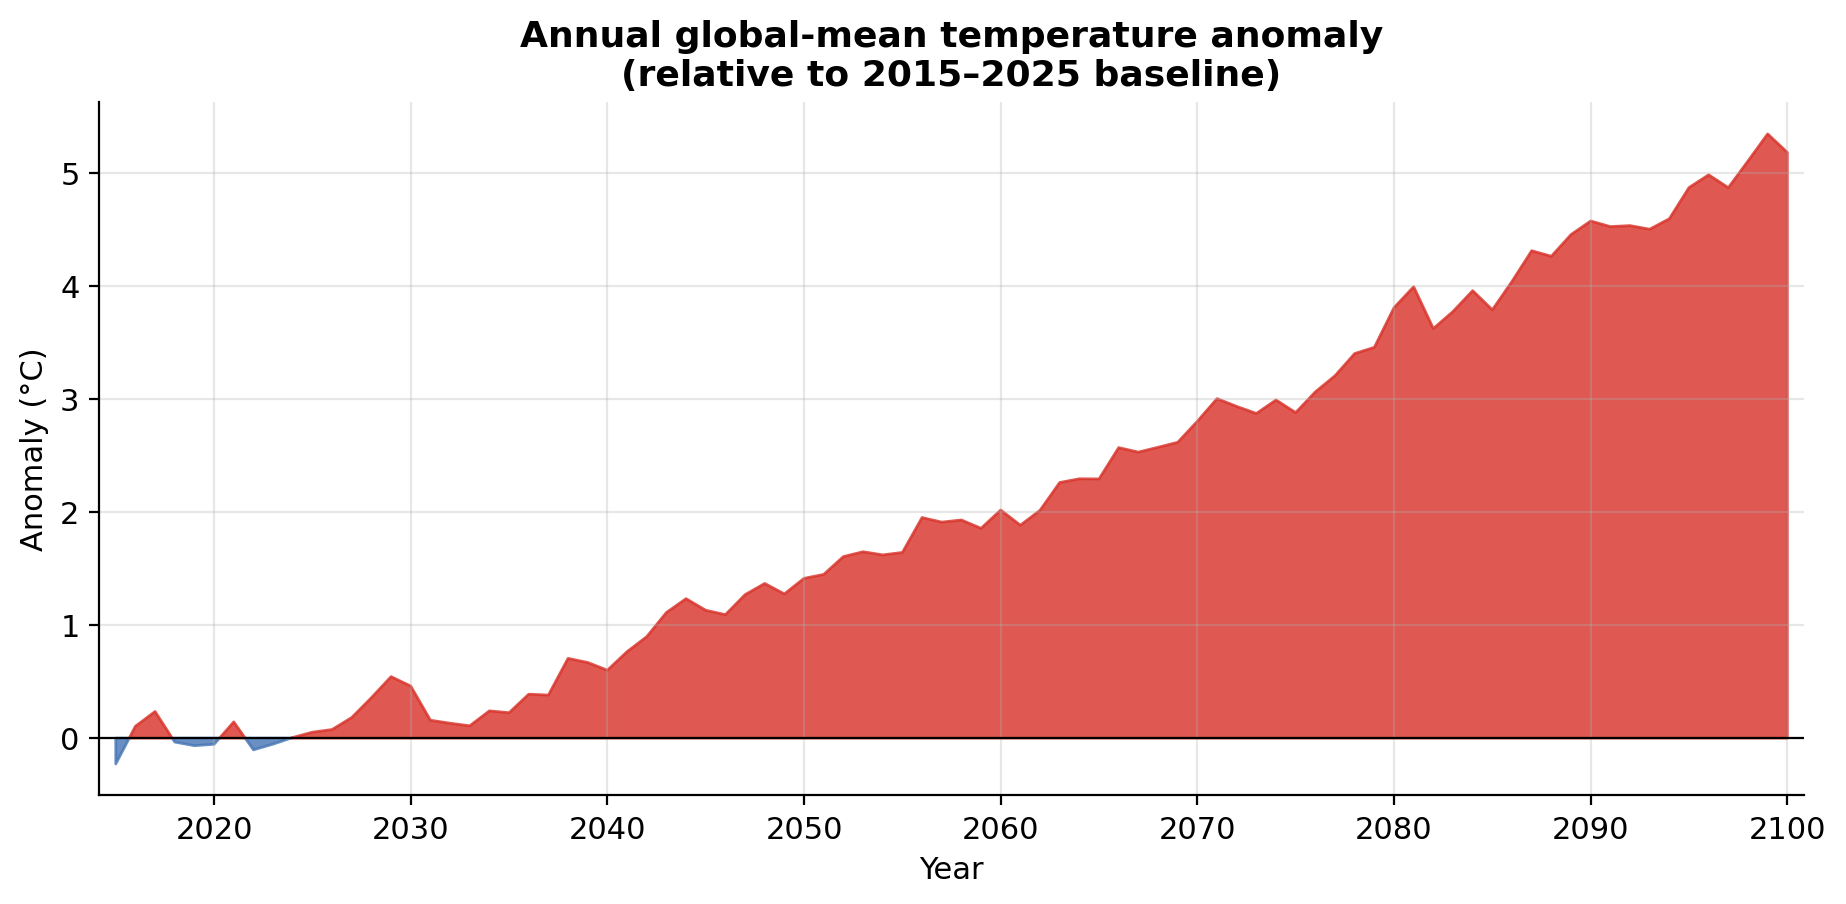

Total warming (2015–2025 → 2025–2035): 0.23 °C


In [15]:
baseline = ta_C.sel(time=slice('2015', '2025')).mean()

anom = ta_C - baseline
annual = anom.groupby('time.year').mean()


fig, ax = plt.subplots(figsize=(11, 4.5))

years = annual['year'].values
vals = annual.values

ax.fill_between(years, vals, where=(vals >= 0), color='#d73027', alpha=0.8, interpolate=True)
ax.fill_between(years, vals, where=(vals < 0),  color='#4575b4', alpha=0.8, interpolate=True)
ax.axhline(0, color='k', lw=0.8)

ax.set_title('Annual global-mean temperature anomaly\n(relative to 2015–2025 baseline)')
ax.set_ylabel('Anomaly (°C)')
ax.set_xlabel('Year')
ax.margins(x=0.01)
plt.show()

print(f'Total warming (2015–2025 → 2025–2035): '
      f'{float(annual.sel(year=slice(2025, 2035)).mean()):.2f} °C')

> **Check your understanding**
>
> 1. Why is 2015–2025 a reasonable baseline for this dataset? What would change if we used pre-industrial (1850–1900)?
> 2. The IPCC reports warming relative to 1850–1900. To do this with SSP5-8.5 data, you would need to **chain** the historical run. What experiment_id would you filter for?
> 3. Why might the end-of-century warming here differ from the ~4.4 °C quoted in the table above?

---

## Exercises

Work through these tasks using what you've learned. Starter code is provided where helpful.

### Exercise 1 — Compare two models

Open a second model from `df_tas`, compute its global-mean temperature series,
and plot both on the same axes.

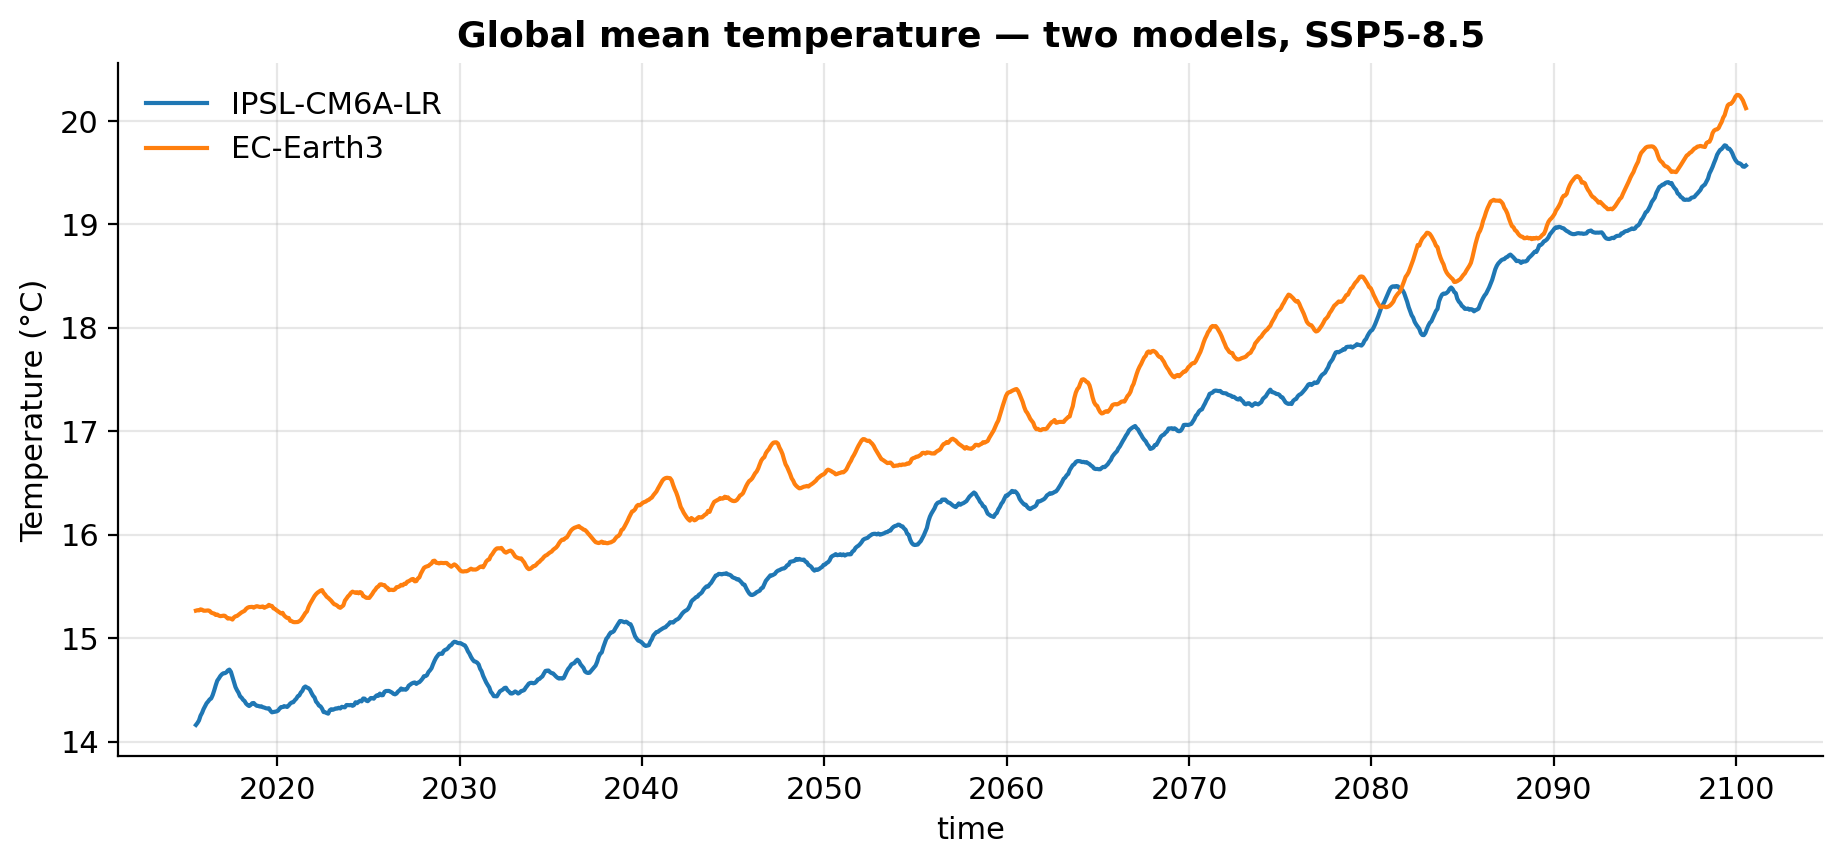

In [16]:
# Hint: pick a second model from df_tas.source_id.unique()
model2 = "EC-Earth3"  # change this

row2 = df_tas[df_tas.source_id == model2].iloc[0]
ds2 = xr.open_zarr(fsspec.get_mapper(row2.zstore), consolidated=True)
ds2_180 = ds2.assign_coords(lon=(ds2.lon + 180) % 360 - 180).sortby("lon")

weights2 = np.cos(np.deg2rad(ds2_180.lat))
ta2 = ds2_180.tas.weighted(weights2).mean(dim=["lon", "lat"]).load() - 273.15

fig, ax = plt.subplots(figsize=(11, 4.5))

# --- your plotting code here ---
ta_C.rolling(time=12, center=True).mean().plot(ax=ax, label=model)
ta2.rolling(time=12, center=True).mean().plot(ax=ax, label=model2)

ax.set_title("Global mean temperature — two models, SSP5-8.5")
ax.set_ylabel("Temperature (°C)")
ax.legend(frameon=False)
plt.show()


### Exercise 2 — Change the scenario

Repeat the global-mean time series for `IPSL-CM6A-LR` but with the **SSP1-2.6 (low emissions)** scenario.
Plot it alongside the SSP5-8.5 series computed above.

**You need to:** re-filter `df` for `experiment_id = "ssp126"`, open the store, compute and plot.

In [17]:
# Your code here
# Step 1: filter df for ssp126, same model (IPSL-CM6A-LR), same ensemble/table/grid
# Step 2: open the zarr store
# Step 3: compute weighted global mean
# Step 4: plot against ta_C from above


### Exercise 3 — Warming map (2080–2100 vs 2015–2035)

Compute the **spatial pattern of warming** by differencing two 20-year mean temperature fields:

```
warming = mean(tas, 2080–2100) − mean(tas, 2015–2035)
```

Plot the result as a global map. What spatial pattern do you see?

In [18]:
# Your code here
# Hint: use .sel(time=slice(...)).mean("time") for each period
# Then subtract and plot with cmap='Reds'


---

## Summary

| Step | Key method | What happens |
|---|---|---|
| Filter catalogue | `df[conditions]` | Find matching Zarr store URLs |
| Open store | `xr.open_zarr(..., consolidated=True)` | Fetch metadata only — lazy |
| Select data | `.sel(time=..., lat=..., lon=...)` | Stream only needed chunks |
| Area-weight | `.weighted(cos_lat).mean(...)` | Correct for grid-cell size |
| Compute | `.load()` | Actually download and run |
| Anomaly | `data - baseline.mean()` | Isolate the climate signal |

**Going further:**
- Concatenate the `historical` run (1850–2014) before SSP5-8.5 for a longer baseline
- Open multiple ensemble members (`r1`, `r2`, `r3`) and plot their spread to visualise internal variability
- Try precipitation (`pr`) — note the units (kg m⁻² s⁻¹) and convert to mm/day
- Load `areacella` from the `fx` table for exact grid-cell areas instead of the cosine approximation